# 🎯 Pose Model Training Pipeline

This notebook documents the complete machine learning pipeline for training a custom pose classifier that predicts user movements (lean_left, neutral, lean_right, jump, crouch) based on MediaPipe landmarks.


---

## 🔍 Step 1: Import Libraries

We import the essential tools for data processing, model building, and visualization.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [2]:
df = pd.read_csv("./dataset.csv")

print(f"Dataset: {len(df)} rows, {len(df['label'].unique())} classes")
print("\nClass Distribution:")
print(df["label"].value_counts().to_string())


Dataset: 3464 rows, 6 classes

Class Distribution:
label
lean_left       1087
crouch           633
neutral          612
lean_right       609
hands_joined     305
jump             218


---

## 🔧 Step 3: Feature Preparation

### Extract Features (X) and Labels (y)

- **X**: Feature matrix (99 columns, one per normalized landmark difference)
- **y**: Target labels (lean_left, neutral, lean_right, jump, crouch)

### Why StandardScaler?

Our MLPClassifier works best when all features are on the same scale. The **StandardScaler** transforms features to have:
- Mean = 0
- Standard Deviation = 1

This prevents features with larger ranges from dominating the model.


In [3]:
feature_cols = [f"f{i}" for i in range(99)]

X = df[feature_cols].values
y = df["label"].values

print(f"X shape: {X.shape}")  # (n_samples, 99)
print(f"y shape: {y.shape}")  # (n_samples,)


X shape: (3464, 99)
y shape: (3464,)


---

## 📅 Step 4: Train/Test Split

We split the data into training (80%) and testing (20%) sets:

- **train_test_split()**: Separates data for training and evaluation
- **stratify=y**: Preserves class distribution in both sets
- **random_state=42**: Ensures reproducible results

This prevents data leakage and gives us an honest evaluation metric.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    stratify=y,           # Keep class proportions
    random_state=42       # Reproducibility
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nClass distribution in training:")
print(y_train.value_counts().to_string())


Training set: 2771 samples
Test set: 693 samples

Class distribution in training:
crouch          506
lean_left       870
hands_joined    244
lean_right      487
neutral         490
jump            174


---

## 🏗️ Step 5: Build the Pipeline

We create a **Pipeline** that chains preprocessing and model steps. This is best practice because:

1. **Single object**: Train the entire pipeline together
2. **No data leakage**: Scaling happens only on training data
3. **Easy deployment**: Export the whole thing at once



In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=1000,
        random_state=42,
        verbose=True,
    )),
])


---

## 🎓 Step 6: Train the Model

The **MLPClassifier (Multi-Layer Perceptron)** is a neural network with:

- **Input layer**: 99 neurons (our features)
- **Hidden layers**: [128] → [64] → [32] neurons
- **Output layer**: 5 neurons (one per class)

### What's Happening?

1. **Epochs**: `max_iter=1000` (up to 1000 passes through training data)
2. **Backpropagation**: Model learns by minimizing prediction error
3. **Learning rate**: Automatically tuned via `learning_rate='adaptive'`
4. **Activation functions**: Hidden layers use ReLU (default)

### Parameters Explained

| Parameter | Purpose |
|-----------|---------|
| hidden_layer_sizes | Number of neurons in each hidden layer |
| max_iter | Maximum epochs to train |
| random_state | Reproducible random seed |
| verbose | Show training logs |


In [6]:
print("\nTraining MLP ...")
pipeline.fit(X_train, y_train)



Training MLP ...
Iteration 1, loss = 0.96543306
Iteration 2, loss = 0.17126320
Iteration 3, loss = 0.03703899
Iteration 4, loss = 0.01029527
Iteration 5, loss = 0.00484672
Iteration 6, loss = 0.00320430
Iteration 7, loss = 0.00240348
Iteration 8, loss = 0.00194938
Iteration 9, loss = 0.00163001
Iteration 10, loss = 0.00139060
Iteration 11, loss = 0.00121191
Iteration 12, loss = 0.00106465
Iteration 13, loss = 0.00094303
Iteration 14, loss = 0.00083972
Iteration 15, loss = 0.00076267
Iteration 16, loss = 0.00068405
Iteration 17, loss = 0.00062743
Iteration 18, loss = 0.00057272
Iteration 19, loss = 0.00053178
Iteration 20, loss = 0.00049012
Iteration 21, loss = 0.00045511
Iteration 22, loss = 0.00042450
Iteration 23, loss = 0.00039797
Iteration 24, loss = 0.00037315
Iteration 25, loss = 0.00035182
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:re

---

## 📊 Step 7: Evaluate on Test Data

We predict on the test set and analyze results:

- **classification_report**: Precision, recall, F1-score per class
- **ConfusionMatrixDisplay**: Visualizes prediction errors

### What These Metrics Mean:

| Metric | Definition |
|--------|------------|
| **Precision** | Of all predicted as class X, how many were truly X? |
| **Recall** | Of all truly class X, how many did we catch? |
| **F1-score** | Harmonic mean of precision and recall |


In [7]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

      crouch       1.00      1.00      1.00       127
hands_joined       1.00      1.00      1.00        61
        jump       1.00      1.00      1.00        44
   lean_left       1.00      1.00      1.00       217
  lean_right       1.00      1.00      1.00       122
     neutral       1.00      1.00      1.00       122

    accuracy                           1.00       693
   macro avg       1.00      1.00      1.00       693
weighted avg       1.00      1.00      1.00       693



---

## 📈 Step 8: Visualize Confusion Matrix

The confusion matrix shows:

- **Diagonal**: Correct predictions
- **Off-diagonal**: Misclassifications

This helps identify which pose states are often confused (e.g., lean_left vs neutral).


confusion_matrix.png saved


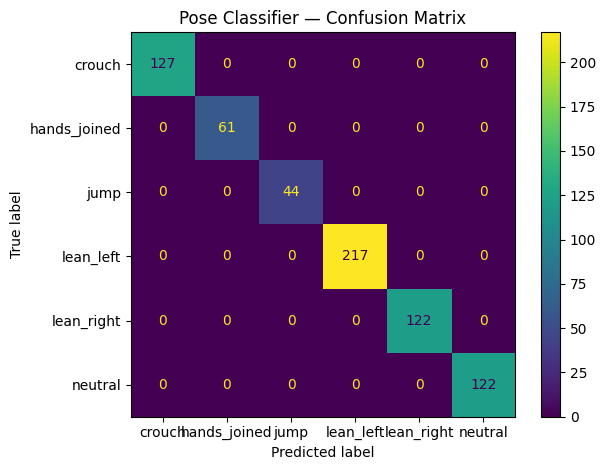

In [8]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Pose Classifier — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
print("confusion_matrix.png saved")


---

## 💾 Step 9: Export the Model

Save the trained pipeline using joblib:

- **Why joblib?** Handles sklearn objects efficiently
- **Format**: Pickle serialization
- **Loading**: joblib.load("pose_model.pkl")

The saved model includes:
1. The fitted StandardScaler (mean/std from training data)
2. The trained MLPClassifier weights

> ⚠️ **Important**: Always refit on training data before deployment, unless using the saved model directly!



In [9]:
joblib.dump(pipeline, "pose_model.pkl")
print("pose_model.pkl saved")

loaded_model = joblib.load("pose_model.pkl")
print(f"Model loaded successfully: {loaded_model}")


pose_model.pkl saved
Model loaded successfully: Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000,
                               random_state=42, verbose=True))])


---

## 🎯 Summary

### What We Built:

1. **Dataset**: 99 landmark features + 5 pose classes
2. **Preprocessing**: StandardScaler normalizes features
3. **Model**: MLP with 3 hidden layers (128 → 64 → 32)
4. **Training**: Up to 1000 epochs
5. **Evaluation**: Classification metrics + confusion matrix
6. **Export**: Saved pipeline with joblib

### Next Steps:

1. **Use in 3_play.py**: Load model and make predictions
2. **Hyperparameter tuning**: Experiment with layer sizes or learning rate
3. **Cross-validation**: Use cross_val_score for more robust evaluation
4. **ONNX export**: Convert to ONNX format for Rust deployment

---